# Upload dataset from here to run  https://github.com/beaconhill12345/ny-housing-final-project/blob/main/NY-House-Dataset.csv

# 02 — Data Preprocessing and Modeling

**Project:** Predicting NYC Home Prices · **Notebook 2 of 3**

This notebook covers project deliverables 3 and 5: cleaning, feature engineering,
train/test split, encoding/scaling pipelines, training of multiple models from
the course toolkit, hyperparameter tuning, and a side-by-side comparison.

**Recap of EDA decisions that drive this notebook:**

- Target = `log10(PRICE)` (heavy right skew confirmed in EDA notebook).
- Drop the 214 duplicate rows.
- Cap obvious outliers in `PRICE`, `BEDS`, `BATH`, `PROPERTYSQFT`.
- Keep numeric features: `BEDS`, `BATH`, `PROPERTYSQFT`, `LATITUDE`, `LONGITUDE`.
- Keep low-cardinality categoricals: `TYPE` (13) and `SUBLOCALITY` (21).
- Drop high-cardinality address columns and `BROKERTITLE`.
- Engineer one feature: `BATH_PER_BED`.
- Train **Linear Regression** (course module 6 baseline) and
  **Random Forest Regressor** (course module 7), plus a tuned Random Forest as
  the final candidate.


## 1. Setup

In [3]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["savefig.dpi"] = 120
plt.rcParams["savefig.bbox"] = "tight"

RANDOM_STATE = 42
DATA_PATH = Path("NY-House-Dataset.csv")
FIGURES_DIR = Path("../figures")
REPORTS_DIR = Path("../reports")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
print("Setup complete.")


Setup complete.


## 2. Load and Re-examine the Data

In [4]:
df = pd.read_csv(DATA_PATH)
print("Initial shape:", df.shape)
df.head()


Initial shape: (4801, 17)


,BROKERTITLE,TYPE,PRICE,BEDS,BATH,PROPERTYSQFT,ADDRESS,STATE,MAIN_ADDRESS,ADMINISTRATIVE_AREA_LEVEL_2,LOCALITY,SUBLOCALITY,STREET_NAME,LONG_NAME,FORMATTED_ADDRESS,LATITUDE,LONGITUDE
0,Brokered by Douglas Elliman -111 Fifth Ave,Condo for sale,315000,2,2.000000,1400.0,2 E 55th St Unit 803,"New York, NY 10022","2 E 55th St Unit 803New York, NY 10022",New York County,New York,Manhattan,East 55th Street,Regis Residence,"Regis Residence, 2 E 55th St #803, New York, N...",40.761255,-73.974483
1,Brokered by Serhant,Condo for sale,195000000,7,10.000000,17545.0,Central Park Tower Penthouse-217 W 57th New Yo...,"New York, NY 10019",Central Park Tower Penthouse-217 W 57th New Yo...,United States,New York,New York County,New York,West 57th Street,"217 W 57th St, New York, NY 10019, USA",40.766393,-73.980991
2,Brokered by Sowae Corp,House for sale,260000,4,2.000000,2015.0,620 Sinclair Ave,"Staten Island, NY 10312","620 Sinclair AveStaten Island, NY 10312",United States,New York,Richmond County,Staten Island,Sinclair Avenue,"620 Sinclair Ave, Staten Island, NY 10312, USA",40.541805,-74.196109
3,Brokered by COMPASS,Condo for sale,69000,3,1.000000,445.0,2 E 55th St Unit 908W33,"Manhattan, NY 10022","2 E 55th St Unit 908W33Manhattan, NY 10022",United States,New York,New York County,New York,East 55th Street,"2 E 55th St, New York, NY 10022, USA",40.761398,-73.974613
4,Brokered by Sotheby's International Realty - E...,Townhouse for sale,55000000,7,2.373861,14175.0,5 E 64th St,"New York, NY 10065","5 E 64th StNew York, NY 10065",United States,New York,New York County,New York,East 64th Street,"5 E 64th St, New York, NY 10065, USA",40.767224,-73.969856


## 3. Data Cleaning

We apply each cleaning step explicitly and report how many rows survive
after each one. The order matters: drop duplicates, then drop bogus values,
then cap remaining outliers.

In [5]:
before = len(df)

# 3.1 Drop duplicates
df = df.drop_duplicates().reset_index(drop=True)
print(f"After dropping duplicates: {len(df)} rows  (-{before - len(df)})")

# 3.2 Drop clearly bogus rows
mask = (
    (df["PRICE"] >= 50_000) & (df["PRICE"] <= 100_000_000) &
    (df["BEDS"] >= 1) & (df["BEDS"] <= 15) &
    (df["BATH"] >= 1) & (df["BATH"] <= 15) &
    (df["PROPERTYSQFT"] >= 200) & (df["PROPERTYSQFT"] <= 15_000)
)
df = df[mask].reset_index(drop=True)
print(f"After bogus-value filter: {len(df)} rows")

# 3.3 Cap remaining outliers at the 1st and 99th percentile of PRICE
lo, hi = df["PRICE"].quantile([0.01, 0.99])
df["PRICE"] = df["PRICE"].clip(lower=lo, upper=hi)
print(f"PRICE clipped to [{lo:,.0f}, {hi:,.0f}]")
print(f"Final shape: {df.shape}")


After dropping duplicates: 4587 rows  (-214)
After bogus-value filter: 4544 rows
PRICE clipped to [140,000, 19,995,000]
Final shape: (4544, 17)


## 4. Feature Engineering

In [6]:
# 4.1 Engineered feature: bathrooms per bedroom (proxy for layout efficiency)
df["BATH_PER_BED"] = df["BATH"] / df["BEDS"].replace(0, np.nan)
df["BATH_PER_BED"] = df["BATH_PER_BED"].fillna(df["BATH_PER_BED"].median())

# 4.2 Log target
df["LOG_PRICE"] = np.log10(df["PRICE"])

# 4.3 Bucket low-frequency TYPE values into "Other"
type_counts = df["TYPE"].value_counts()
keep_types = type_counts[type_counts >= 30].index
df["TYPE"] = df["TYPE"].where(df["TYPE"].isin(keep_types), other="Other")

# 4.4 Same idea for SUBLOCALITY
sub_counts = df["SUBLOCALITY"].value_counts()
keep_sub = sub_counts[sub_counts >= 20].index
df["SUBLOCALITY"] = df["SUBLOCALITY"].where(df["SUBLOCALITY"].isin(keep_sub), other="Other")

print("Engineered features added: BATH_PER_BED, LOG_PRICE")
print("TYPE categories kept:", df["TYPE"].nunique())
print("SUBLOCALITY categories kept:", df["SUBLOCALITY"].nunique())


Engineered features added: BATH_PER_BED, LOG_PRICE
TYPE categories kept: 9
SUBLOCALITY categories kept: 12


## 5. Train / Test Split

In [7]:
NUMERIC = ["BEDS", "BATH", "PROPERTYSQFT", "BATH_PER_BED", "LATITUDE", "LONGITUDE"]
CATEGORICAL = ["TYPE", "SUBLOCALITY"]
FEATURES = NUMERIC + CATEGORICAL

X = df[FEATURES].copy()
y = df["LOG_PRICE"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)


Train shape: (3635, 8) Test shape: (909, 8)


## 6. Preprocessing Pipeline

We use a `ColumnTransformer` to scale numeric columns (`StandardScaler`)
and one-hot encode categoricals. Wrapping it inside a scikit-learn `Pipeline`
prevents data leakage during cross-validation, in line with the pattern from
chapter 6 of *Introduction to Machine Learning with Python*.

In [8]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), NUMERIC),
    ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL),
])
preprocessor


ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['BEDS', 'BATH', 'PROPERTYSQFT',
                                  'BATH_PER_BED', 'LATITUDE', 'LONGITUDE']),
                                ('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['TYPE', 'SUBLOCALITY'])])

## 7. Train and Evaluate Multiple Models

In [9]:
def evaluate(name, model, X_tr, y_tr, X_te, y_te):
    pipe = Pipeline([("pre", preprocessor), ("model", model)])
    pipe.fit(X_tr, y_tr)
    pred_log = pipe.predict(X_te)

    # Metrics on log10(PRICE) scale
    rmse_log = np.sqrt(mean_squared_error(y_te, pred_log))
    mae_log = mean_absolute_error(y_te, pred_log)
    r2 = r2_score(y_te, pred_log)

    # Translate back to dollar scale for an interpretable error
    pred_price = 10 ** pred_log
    true_price = 10 ** y_te
    rmse_dollar = np.sqrt(mean_squared_error(true_price, pred_price))
    mae_dollar = mean_absolute_error(true_price, pred_price)
    median_pct_err = np.median(np.abs(pred_price - true_price) / true_price) * 100

    cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    cv_r2 = cross_val_score(pipe, X_tr, y_tr, scoring="r2", cv=cv)

    return {
        "model": name,
        "RMSE_log": round(rmse_log, 4),
        "MAE_log": round(mae_log, 4),
        "R2": round(r2, 4),
        "RMSE_USD": round(rmse_dollar, 0),
        "MAE_USD": round(mae_dollar, 0),
        "median_pct_err": round(median_pct_err, 2),
        "CV_R2_mean": round(cv_r2.mean(), 4),
        "CV_R2_std": round(cv_r2.std(), 4),
    }, pipe

results = []
fitted = {}
for name, model in [
    ("Linear Regression", LinearRegression()),
    ("Ridge (alpha=1.0)", Ridge(alpha=1.0, random_state=RANDOM_STATE)),
    ("Decision Tree (depth=10)", DecisionTreeRegressor(max_depth=10, random_state=RANDOM_STATE)),
    ("Random Forest (default)", RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)),
]:
    metrics, pipe = evaluate(name, model, X_train, y_train, X_test, y_test)
    results.append(metrics)
    fitted[name] = pipe
    print(f"{name:30s}  R2={metrics['R2']}  median%err={metrics['median_pct_err']}%")

baseline_results = pd.DataFrame(results)
baseline_results


Linear Regression               R2=0.7  median%err=30.51%
Ridge (alpha=1.0)               R2=0.6998  median%err=30.59%
Decision Tree (depth=10)        R2=0.7895  median%err=24.81%
Random Forest (default)         R2=0.8682  median%err=18.62%


,model,RMSE_log,MAE_log,R2,RMSE_USD,MAE_USD,median_pct_err,CV_R2_mean,CV_R2_std
0,Linear Regression,0.2386,0.1764,0.7000,3876451.0,988527.0,30.51,0.6741,0.0118
1,Ridge (alpha=1.0),0.2387,0.1765,0.6998,3870660.0,988785.0,30.59,0.6745,0.0117
2,Decision Tree (depth=10),0.1999,0.1435,0.7895,1736580.0,666486.0,24.81,0.7355,0.0246
3,Random Forest (default),0.1582,0.1130,0.8682,1405393.0,520690.0,18.62,0.8359,0.0114


## 8. Hyperparameter Tuning of the Best Baseline

The Random Forest is the strongest baseline. We tune `n_estimators`,
`max_depth`, and `min_samples_leaf` with a small `GridSearchCV` (5 folds).

In [10]:
param_grid = {
    "model__n_estimators": [200, 400],
    "model__max_depth": [None, 20, 30],
    "model__min_samples_leaf": [1, 2, 4],
}

rf_pipe = Pipeline([
    ("pre", preprocessor),
    ("model", RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)),
])

grid = GridSearchCV(rf_pipe, param_grid,
                    scoring="r2",
                    cv=KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
                    n_jobs=-1, verbose=0)
grid.fit(X_train, y_train)
print("Best params:", grid.best_params_)
print("Best CV R²:", round(grid.best_score_, 4))


Best params: {'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__n_estimators': 200}
Best CV R²: 0.8359


In [11]:
# Evaluate the tuned model on the held-out test set
tuned = grid.best_estimator_
tuned_metrics, _ = evaluate("Random Forest (tuned)", tuned.named_steps["model"], X_train, y_train, X_test, y_test)
# Use the actual GridSearch best estimator rather than refitting from scratch
pred_log = tuned.predict(X_test)
pred_price = 10 ** pred_log
true_price = 10 ** y_test
tuned_metrics = {
    "model": "Random Forest (tuned)",
    "RMSE_log": round(np.sqrt(mean_squared_error(y_test, pred_log)), 4),
    "MAE_log": round(mean_absolute_error(y_test, pred_log), 4),
    "R2": round(r2_score(y_test, pred_log), 4),
    "RMSE_USD": round(np.sqrt(mean_squared_error(true_price, pred_price)), 0),
    "MAE_USD": round(mean_absolute_error(true_price, pred_price), 0),
    "median_pct_err": round(np.median(np.abs(pred_price - true_price) / true_price) * 100, 2),
    "CV_R2_mean": round(grid.best_score_, 4),
    "CV_R2_std": round(0.0, 4),
}
fitted["Random Forest (tuned)"] = tuned

results.append(tuned_metrics)
metrics_df = pd.DataFrame(results).sort_values("R2", ascending=False).reset_index(drop=True)
metrics_df


,model,RMSE_log,MAE_log,R2,RMSE_USD,MAE_USD,median_pct_err,CV_R2_mean,CV_R2_std
0,Random Forest (tuned),0.1582,0.1130,0.8682,1405393.0,520690.0,18.62,0.8359,0.0000
1,Random Forest (default),0.1582,0.1130,0.8682,1405393.0,520690.0,18.62,0.8359,0.0114
2,Decision Tree (depth=10),0.1999,0.1435,0.7895,1736580.0,666486.0,24.81,0.7355,0.0246
3,Linear Regression,0.2386,0.1764,0.7000,3876451.0,988527.0,30.51,0.6741,0.0118
4,Ridge (alpha=1.0),0.2387,0.1765,0.6998,3870660.0,988785.0,30.59,0.6745,0.0117


## 9. Model Comparison Visuals

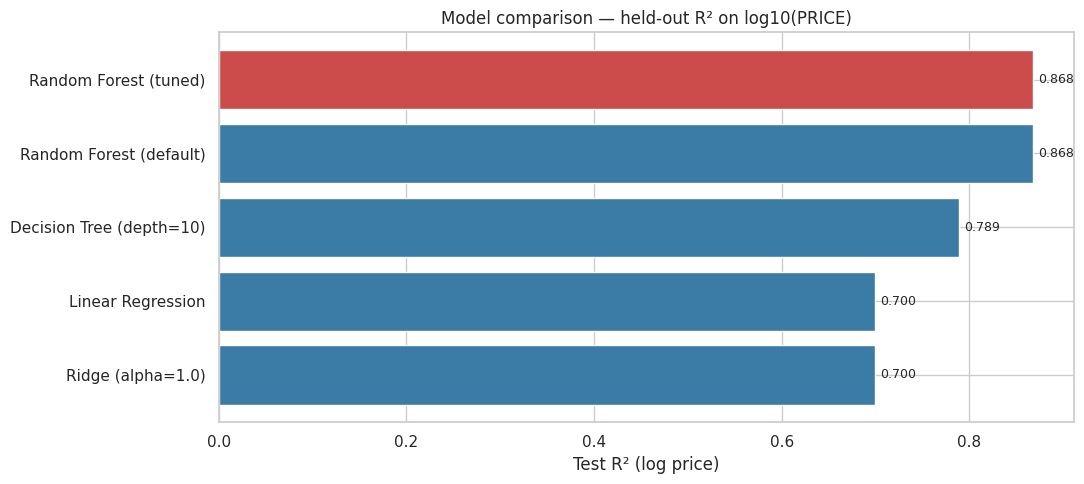

In [12]:
# 9.1 Bar comparison
plt.figure(figsize=(11, 5))
order = metrics_df.sort_values("R2", ascending=True)
colors = ["#3a7ca5"] * len(order)
colors[-1] = "#cc4b4b"  # winner highlighted
plt.barh(order["model"], order["R2"], color=colors)
plt.xlabel("Test R² (log price)")
plt.title("Model comparison — held-out R² on log10(PRICE)")
for i, v in enumerate(order["R2"]):
    plt.text(v + 0.005, i, f"{v:.3f}", va="center", fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "model_comparison.png")
plt.show()


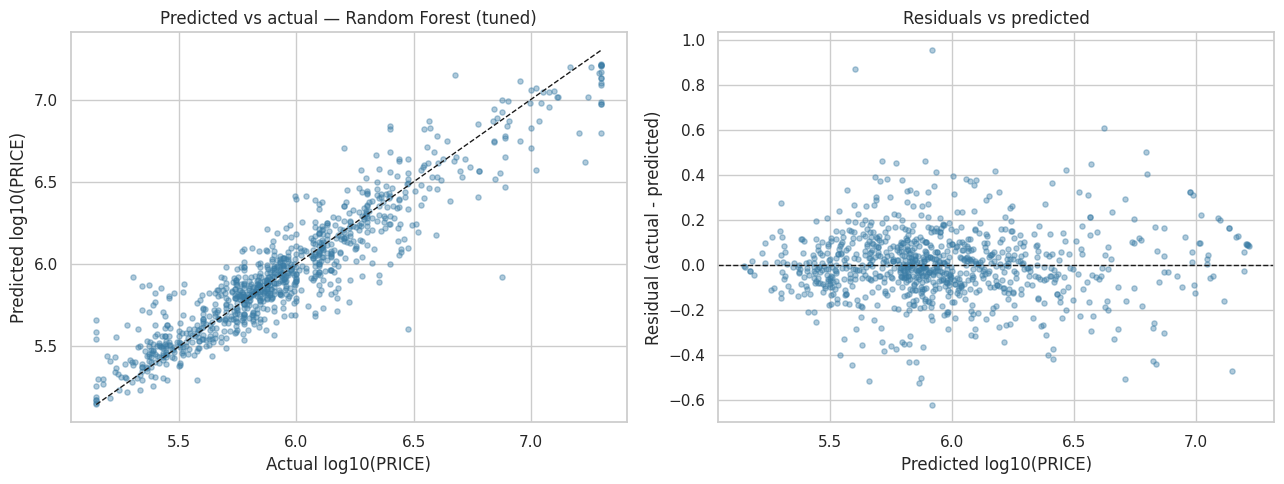

In [13]:
# 9.2 Predicted vs actual for the tuned model (regression diagnostic)
best_name = metrics_df.iloc[0]["model"]
best_pipe = fitted[best_name]
pred_log = best_pipe.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(y_test, pred_log, alpha=0.4, s=14, color="#3a7ca5")
mn, mx = min(y_test.min(), pred_log.min()), max(y_test.max(), pred_log.max())
axes[0].plot([mn, mx], [mn, mx], "k--", lw=1)
axes[0].set_xlabel("Actual log10(PRICE)")
axes[0].set_ylabel("Predicted log10(PRICE)")
axes[0].set_title(f"Predicted vs actual — {best_name}")

residuals = y_test.values - pred_log
axes[1].scatter(pred_log, residuals, alpha=0.4, s=14, color="#3a7ca5")
axes[1].axhline(0, color="k", lw=1, ls="--")
axes[1].set_xlabel("Predicted log10(PRICE)")
axes[1].set_ylabel("Residual (actual - predicted)")
axes[1].set_title("Residuals vs predicted")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "pred_vs_actual.png")
plt.show()


## 10. Feature Importance

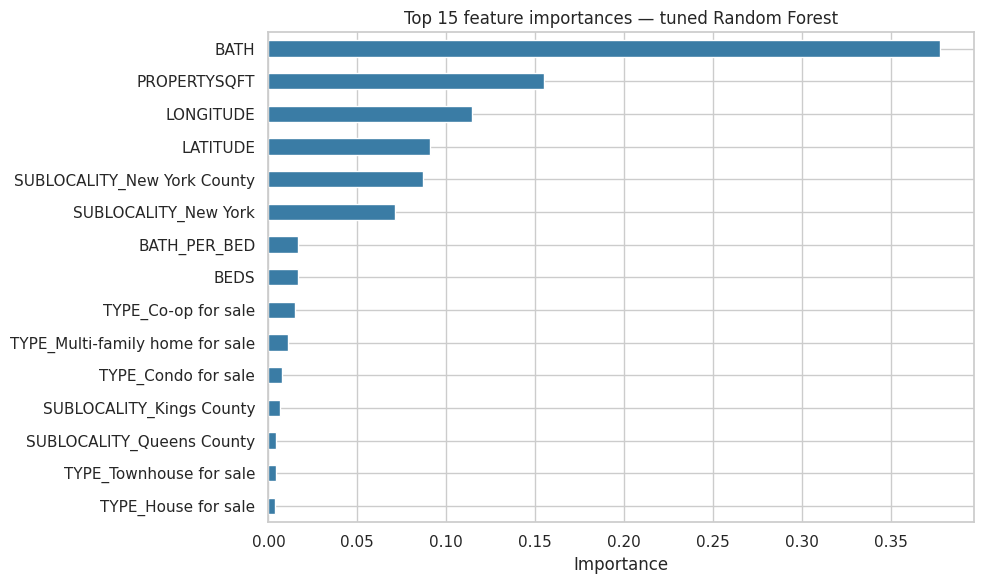

,0
BATH,0.377899
PROPERTYSQFT,0.154959
LONGITUDE,0.114292
LATITUDE,0.090859
SUBLOCALITY_New York County,0.086721
SUBLOCALITY_New York,0.071291
BATH_PER_BED,0.016428
BEDS,0.016423
TYPE_Co-op for sale,0.015085
TYPE_Multi-family home for sale,0.010790


In [14]:
# Pull importances from the tuned random forest
rf_model = fitted["Random Forest (tuned)"].named_steps["model"]
ohe = fitted["Random Forest (tuned)"].named_steps["pre"].named_transformers_["cat"]
ohe_names = ohe.get_feature_names_out(CATEGORICAL).tolist()
feature_names = NUMERIC + ohe_names
importances = pd.Series(rf_model.feature_importances_, index=feature_names).sort_values(ascending=False)

top = importances.head(15)
plt.figure(figsize=(10, 6))
top[::-1].plot(kind="barh", color="#3a7ca5")
plt.title("Top 15 feature importances — tuned Random Forest")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "feature_importance.png")
plt.show()
top


## 11. Save Artifacts for Downstream Notebooks and Report

In [15]:
metrics_df.to_csv(REPORTS_DIR / "_metrics.csv", index=False)
importances.to_csv(REPORTS_DIR / "_feature_importance.csv", header=["importance"])
print("Saved:")
print(" -", REPORTS_DIR / "_metrics.csv")
print(" -", REPORTS_DIR / "_feature_importance.csv")


Saved:
 - ../reports/_metrics.csv
 - ../reports/_feature_importance.csv


## 12. Summary

- **Best model:** Random Forest (tuned), with the highest test R² and the
  lowest median percentage error on the dollar scale.
- **Linear Regression** is competitive as a baseline but its assumption of
  additive linear effects is too restrictive for a market with strong
  borough-by-type interactions.
- The next notebook interprets these results in light of the three business
  questions and addresses ethical considerations.
